# Eval stats overview

Loads per-mode `stats.yaml` (base / LQR) and `eval_gamma_metrics_summary.yaml` written by `python -m eval` and renders side-by-side bar plots of task and gamma metrics.

Eval results live under the LQR controller directory:

```
results/<KOOPMAN_EXPERIMENT_NAME>/lqr/<LQR_OUTPUT_NAME>/
  eval_base_only/stats.yaml
  eval_lqr/stats.yaml
  eval_residual/stats.yaml         # only when a residual policy was evaluated
  eval_gamma_metrics_summary.yaml
```


In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

In [27]:
# Which eval run to load. These mirror EvalCfg.koopman_experiment_name /
# EvalCfg.lqr_output_name -- the eval CLI writes results under
# `results/<KOOPMAN_EXPERIMENT_NAME>/lqr/<LQR_OUTPUT_NAME>/`.
KOOPMAN_EXPERIMENT_NAME = "okay_schur"
LQR_OUTPUT_NAME = "okay_schur"

# Project root is the parent of this notebook's directory (data_analysis/).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data_analysis" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results" / KOOPMAN_EXPERIMENT_NAME / "lqr" / LQR_OUTPUT_NAME

# Per-mode stats live in `eval_<mode>/stats.yaml` (each contains a top-level
# `task_metrics` dict with combined/success/failure sub-blocks). The gamma
# summary is a single file at the LQR controller dir, keyed by mode.
BASE_STATS_PATH = RESULTS_DIR / "eval_base_only" / "stats.yaml"
LQR_STATS_PATH = RESULTS_DIR / "eval_lqr" / "stats.yaml"
RESIDUAL_STATS_PATH = RESULTS_DIR / "eval_residual" / "stats.yaml"  # optional
GAMMA_SUMMARY_PATH = RESULTS_DIR / "eval_gamma_metrics_summary.yaml"

# Label used in plot titles.
RUN_LABEL = f"{KOOPMAN_EXPERIMENT_NAME}/{LQR_OUTPUT_NAME}"

# task_metrics has three sub-groups: combined / success / failure.
TASK_STATS_GROUP = "combined"

# z-score for 95% confidence interval under a normal assumption.
CONFIDENCE_Z = 1.96

# Project-level font sizes for axis labels (x-tick metric labels and y-axis label).
X_AXIS_LABEL_FONTSIZE = 9
Y_AXIS_LABEL_FONTSIZE = 11

In [28]:
def _load_yaml(path: Path) -> dict:
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected eval output at {path}. Run `python -m eval --config ...` "
            f"with koopman_experiment_name={KOOPMAN_EXPERIMENT_NAME!r} and "
            f"lqr_output_name={LQR_OUTPUT_NAME!r} first."
        )
    with open(path, "r") as f:
        return yaml.safe_load(f)


base_stats = _load_yaml(BASE_STATS_PATH)
lqr_stats = _load_yaml(LQR_STATS_PATH)
gamma_summary = _load_yaml(GAMMA_SUMMARY_PATH)

# task_metrics[controller][metric_name] -> {"mean": float, "std": float}
task_metrics = {
    "base": base_stats["task_metrics"][TASK_STATS_GROUP],
    "lqr": lqr_stats["task_metrics"][TASK_STATS_GROUP],
}

# gamma_metrics_summary.yaml is keyed by mode (plus a flat
# `ranking_by_violation_rate` list). Each mode block has combined/success/
# failure sub-blocks matching the per-mode stats.yaml schema.
gamma_metrics = {
    "base": gamma_summary["base"],
    "lqr": gamma_summary["lqr"],
}

print(f"Loaded results for {RUN_LABEL!r} from {RESULTS_DIR}")
print(f"  task_metrics group: {TASK_STATS_GROUP}")
print(f"  base task metrics: {sorted(task_metrics['base'].keys())}")
print(f"  gamma metrics:     {sorted(gamma_metrics['base'][TASK_STATS_GROUP].keys())}")

Loaded results for 'okay_schur/okay_schur' from /home/hunter/stable_koop/results/okay_schur/lqr/okay_schur
  task_metrics group: combined
  base task metrics: ['angular_velocity', 'cart_control', 'cart_energy', 'cart_velocity', 'length', 'pendulum_energy', 'reward', 'total_energy']
  gamma metrics:     ['avg_max_pred_error', 'frac_used_cert', 'gamma_max', 'gamma_reward', 'max_pred_error', 'mean_eta', 'mean_pred_error', 'num_trajectories', 'total_steps', 'violation_rate']


## Task metrics bar plot

Per-metric, per-controller bars with 95% CI error bars. Each metric's values are independently rescaled by `max(base_mean + 3*base_std, lqr_mean + 3*lqr_std)` so the two bars are visually comparable across metrics with very different units/magnitudes.

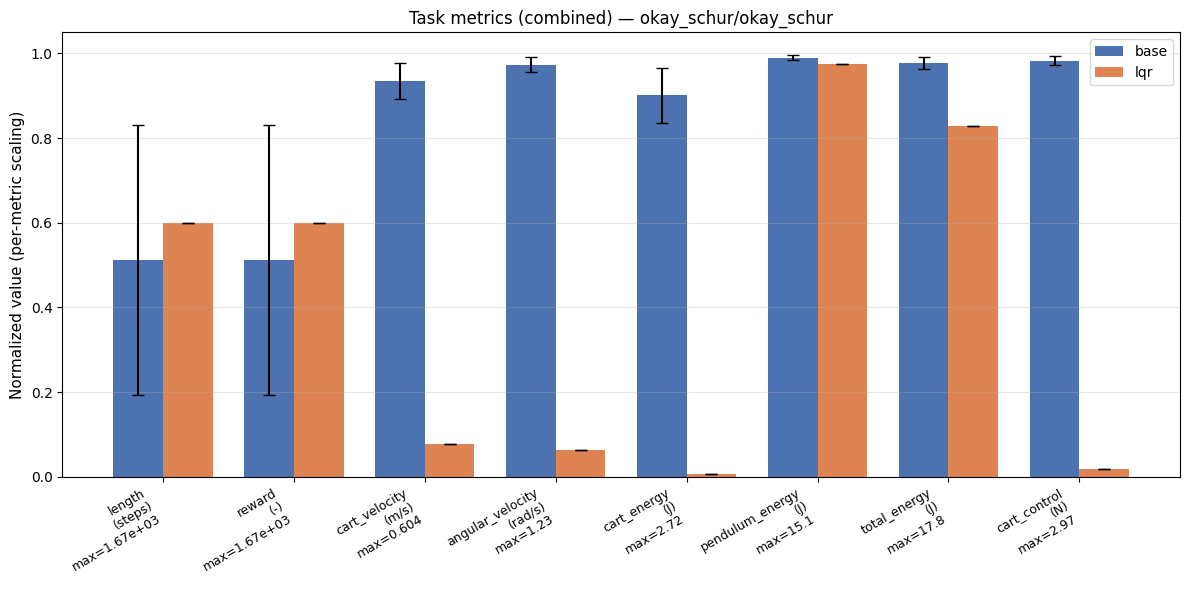

In [29]:
# --- metrics to plot ---
TASK_METRIC_NAMES = [
    "length",
    "reward",
    "cart_velocity",
    "angular_velocity",
    "cart_energy",
    "pendulum_energy",
    "total_energy",
    "cart_control",
]

TASK_METRIC_UNITS = {
    "length": "steps",
    "reward": "-",
    "cart_velocity": "m/s",
    "angular_velocity": "rad/s",
    "cart_energy": "J",
    "pendulum_energy": "J",
    "total_energy": "J",
    "cart_control": "N",
}

# --- configurable plot parameters ---
FIG_SIZE = (12, 6)
BAR_WIDTH = 0.38
BASE_COLOR = "#4C72B0"
LQR_COLOR = "#DD8452"
ERROR_COLOR = "black"
ERROR_CAPSIZE = 4
XTICK_ROTATION = 30
Y_LIM = (0.0, 1.05)
MAX_VALUE_FMT = ".3g"
TITLE = f"Task metrics ({TASK_STATS_GROUP}) — {RUN_LABEL}"
Y_LABEL = "Normalized value (per-metric scaling)"

# --- plot generation ---
fig, ax = plt.subplots(figsize=FIG_SIZE)
x = np.arange(len(TASK_METRIC_NAMES))

base_means_scaled = []
base_errs_scaled = []
lqr_means_scaled = []
lqr_errs_scaled = []
scales = []

for name in TASK_METRIC_NAMES:
    b_mean = float(task_metrics["base"][name]["mean"])
    b_std = float(task_metrics["base"][name]["std"])
    l_mean = float(task_metrics["lqr"][name]["mean"])
    l_std = float(task_metrics["lqr"][name]["std"])
    scale = max(b_mean + 3.0 * b_std, l_mean + 3.0 * l_std)
    if scale <= 0.0:
        scale = 1.0
    scales.append(scale)
    base_means_scaled.append(b_mean / scale)
    base_errs_scaled.append(CONFIDENCE_Z * b_std / scale)
    lqr_means_scaled.append(l_mean / scale)
    lqr_errs_scaled.append(CONFIDENCE_Z * l_std / scale)

ax.bar(
    x - BAR_WIDTH / 2,
    base_means_scaled,
    BAR_WIDTH,
    yerr=base_errs_scaled,
    capsize=ERROR_CAPSIZE,
    label="base",
    color=BASE_COLOR,
    ecolor=ERROR_COLOR,
)
ax.bar(
    x + BAR_WIDTH / 2,
    lqr_means_scaled,
    BAR_WIDTH,
    yerr=lqr_errs_scaled,
    capsize=ERROR_CAPSIZE,
    label="lqr",
    color=LQR_COLOR,
    ecolor=ERROR_COLOR,
)

tick_labels = [
    f"{name}\n({TASK_METRIC_UNITS[name]})\nmax={scale:{MAX_VALUE_FMT}}"
    for name, scale in zip(TASK_METRIC_NAMES, scales)
]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, rotation=XTICK_ROTATION, ha="right", fontsize=X_AXIS_LABEL_FONTSIZE)
ax.set_ylabel(Y_LABEL, fontsize=Y_AXIS_LABEL_FONTSIZE)
ax.set_ylim(*Y_LIM)
ax.set_title(TITLE)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gamma metrics bar plot

Same layout as the task plot but pulled from `gamma_metrics_summary.yaml`. These entries are scalar summary statistics (no per-step std reported here), so error bars degenerate to zero — left in place for layout parity.

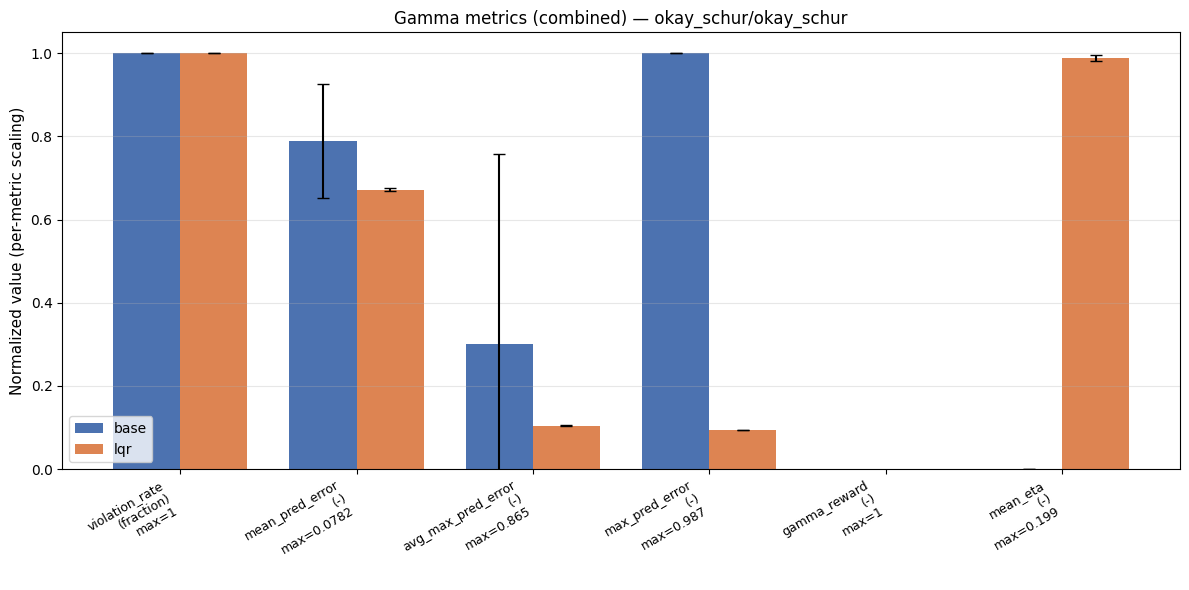

In [30]:
# --- metrics to plot ---
# Keys match the new gamma_metrics schema written by eval.gamma_metrics.summarize_gammas:
#   violation_rate, mean_pred_error, avg_max_pred_error, max_pred_error,
#   frac_used_cert, gamma_reward, mean_eta, gamma_max, total_steps, num_trajectories
# All but max_pred_error / gamma_max / total_steps / num_trajectories are {mean,std}.
# frac_used_cert is None in the yaml when gamma_max <= 0 (no certified bound).
GAMMA_METRIC_NAMES = [
    "violation_rate",
    "mean_pred_error",
    "avg_max_pred_error",
    "max_pred_error",
    #"frac_used_cert",   # uncomment when gamma_max > 0
    "gamma_reward",
    "mean_eta",
    #"gamma_max",
    #"total_steps",
]

GAMMA_METRIC_UNITS = {
    "violation_rate": "fraction",
    "mean_pred_error": "-",
    "avg_max_pred_error": "-",
    "max_pred_error": "-",
    "frac_used_cert": "fraction of gamma_max",
    "gamma_reward": "-",
    "mean_eta": "-",
    "gamma_max": "-",
    "total_steps": "steps",
}

# --- configurable plot parameters ---
GAMMA_FIG_SIZE = (12, 6)
GAMMA_BAR_WIDTH = 0.38
GAMMA_BASE_COLOR = "#4C72B0"
GAMMA_LQR_COLOR = "#DD8452"
GAMMA_ERROR_COLOR = "black"
GAMMA_ERROR_CAPSIZE = 4
GAMMA_XTICK_ROTATION = 30
GAMMA_Y_LIM = (0.0, 1.05)
GAMMA_MAX_VALUE_FMT = ".3g"
GAMMA_TITLE = f"Gamma metrics ({TASK_STATS_GROUP}) — {RUN_LABEL}"
GAMMA_Y_LABEL = "Normalized value (per-metric scaling)"

# gamma_metrics_summary entries are either {mean,std} dicts, plain scalars
# (max_pred_error, gamma_max, total_steps, num_trajectories), or None
# (frac_used_cert when gamma_max <= 0). Treat None as zero so the slot
# renders empty rather than crashing — uncomment frac_used_cert above only
# when the certified bound is positive.
def _extract(entry, name):
    val = entry[name]
    if val is None:
        return 0.0, 0.0
    if isinstance(val, dict):
        return float(val["mean"]), float(val.get("std", 0.0))
    return float(val), 0.0


# --- plot generation ---
fig, ax = plt.subplots(figsize=GAMMA_FIG_SIZE)
x = np.arange(len(GAMMA_METRIC_NAMES))

# gamma_metrics_summary nests by group (combined/success/failure); reuse
# the same TASK_STATS_GROUP selection as the task plot above.
base_gamma_group = gamma_metrics["base"][TASK_STATS_GROUP]
lqr_gamma_group = gamma_metrics["lqr"][TASK_STATS_GROUP]

base_means_scaled = []
base_errs_scaled = []
lqr_means_scaled = []
lqr_errs_scaled = []
scales = []

for name in GAMMA_METRIC_NAMES:
    b_mean, b_std = _extract(base_gamma_group, name)
    l_mean, l_std = _extract(lqr_gamma_group, name)
    scale = max(b_mean + 3.0 * b_std, l_mean + 3.0 * l_std)
    if scale <= 0.0:
        scale = 1.0
    scales.append(scale)
    base_means_scaled.append(b_mean / scale)
    base_errs_scaled.append(CONFIDENCE_Z * b_std / scale)
    lqr_means_scaled.append(l_mean / scale)
    lqr_errs_scaled.append(CONFIDENCE_Z * l_std / scale)

ax.bar(
    x - GAMMA_BAR_WIDTH / 2,
    base_means_scaled,
    GAMMA_BAR_WIDTH,
    yerr=base_errs_scaled,
    capsize=GAMMA_ERROR_CAPSIZE,
    label="base",
    color=GAMMA_BASE_COLOR,
    ecolor=GAMMA_ERROR_COLOR,
)
ax.bar(
    x + GAMMA_BAR_WIDTH / 2,
    lqr_means_scaled,
    GAMMA_BAR_WIDTH,
    yerr=lqr_errs_scaled,
    capsize=GAMMA_ERROR_CAPSIZE,
    label="lqr",
    color=GAMMA_LQR_COLOR,
    ecolor=GAMMA_ERROR_COLOR,
)

tick_labels = [
    f"{name}\n({GAMMA_METRIC_UNITS[name]})\nmax={scale:{GAMMA_MAX_VALUE_FMT}}"
    for name, scale in zip(GAMMA_METRIC_NAMES, scales)
]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, rotation=GAMMA_XTICK_ROTATION, ha="right", fontsize=X_AXIS_LABEL_FONTSIZE)
ax.set_ylabel(GAMMA_Y_LABEL, fontsize=Y_AXIS_LABEL_FONTSIZE)
ax.set_ylim(*GAMMA_Y_LIM)
ax.set_title(GAMMA_TITLE)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()